# Graph basics

An **undirected graph** consists of vertices and edges. An adjacency list maps each vertex to its neighbors.

Run the cells below to explore a small graph. Try adding a vertex and an edge, remembering to update both endpoints' neighbor lists.

In [1]:
graph = {
    "A": ["B", "C"],
    "B": ["A", "D"],
    "C": ["A", "D"],
    "D": ["B", "C", "E"],
    "E": ["D"],
}

for vertex, neighbors in graph.items():
    print(f"{vertex} is connected to {', '.join(neighbors)}")

A is connected to B, C
B is connected to A, D
C is connected to A, D
D is connected to B, C, E
E is connected to D


## Degrees and the handshaking lemma

A vertex's **degree** is the number of edges incident to it. For this graph, that is the length of its neighbor list.

Each undirected edge appears twice in the adjacency list, so the sum of all degrees is twice the number of edges.

In [2]:
degrees = {vertex: len(neighbors) for vertex, neighbors in graph.items()}
edges = {frozenset((vertex, neighbor)) for vertex, neighbors in graph.items() for neighbor in neighbors}

print(f"Vertices: {len(graph)}")
print(f"Edges: {len(edges)}")
print(f"Degrees: {degrees}")
print(f"Sum of degrees: {sum(degrees.values())}")
assert sum(degrees.values()) == 2 * len(edges)
print("Handshaking lemma verified!")

Vertices: 5
Edges: 5
Degrees: {'A': 2, 'B': 2, 'C': 2, 'D': 3, 'E': 1}
Sum of degrees: 10
Handshaking lemma verified!


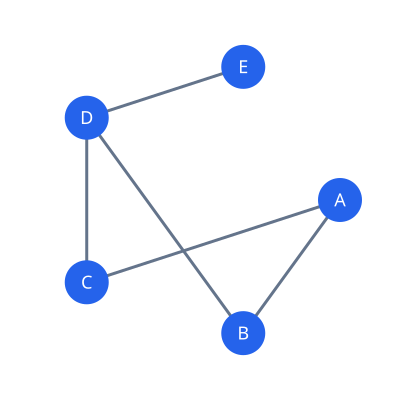

In [3]:
from html import escape
from math import cos, sin, tau

from IPython.display import SVG, display

# Arrange vertices around a circle and draw each undirected edge once.
positions = {
    vertex: (200 + 140 * cos(tau * i / len(graph)),
             200 + 140 * sin(tau * i / len(graph)))
    for i, vertex in enumerate(graph)
}
svg_parts = [
    '<svg xmlns="http://www.w3.org/2000/svg" width="400" height="400" '
    'viewBox="0 0 400 400" role="img" aria-label="Undirected graph">',
    '<rect width="400" height="400" fill="white"/>',
]
drawn_edges = set()
for vertex, neighbors in graph.items():
    x1, y1 = positions[vertex]
    for neighbor in neighbors:
        edge = frozenset((vertex, neighbor))
        if edge not in drawn_edges:
            x2, y2 = positions[neighbor]
            svg_parts.append(
                f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" '
                'stroke="#64748b" stroke-width="3"/>'
            )
            drawn_edges.add(edge)
for vertex, (x, y) in positions.items():
    svg_parts.append(f'<circle cx="{x}" cy="{y}" r="22" fill="#2563eb"/>')
    svg_parts.append(
        f'<text x="{x}" y="{y}" text-anchor="middle" dy="0.35em" '
        f'font-family="sans-serif" font-size="18" fill="white">{escape(str(vertex))}</text>'
    )
svg_parts.append('</svg>')
display(SVG(''.join(svg_parts)))